In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmocean 
import cftime
import gsw

### load time mean global Temerpature (T) and Salinity (S) (function of latitude, longitude, and depth)

In [2]:
woa18_data = xr.open_zarr('C:/Users/TU_Climate24_Student/Desktop/Phys_Oc/physical_oceanography/data/woa18_full_decadal_ave_fields')

# ocean depth
etopo5_data = xr.open_dataset('http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NGDC/.ETOPO5/dods')
etopo5_data = etopo5_data.rename({'X': 'lon', 'Y': 'lat'})
etopo5_data['elev_ocean'] = etopo5_data.elev.where(etopo5_data.elev<0).load()
etopo5_data

<xarray.Dataset>
Dimensions:     (lat: 2160, lon: 4320)
Coordinates:
  * lat         (lat) float32 90.0 89.92 89.83 89.75 ... -89.75 -89.83 -89.92
  * lon         (lon) float32 0.0 0.08333 0.1667 0.25 ... 359.8 359.8 359.9
Data variables:
    elev        (lat, lon) int16 -4290 -4290 -4290 -4290 ... 2774 2774 2774 2774
    elev_ocean  (lat, lon) float32 -4.29e+03 -4.29e+03 -4.29e+03 ... nan nan nan
Attributes:
    dataset_documentation.html:  http://iridl.ldeo.columbia.edu/SOURCES/.NOAA...
    Conventions:                 IRIDL
    description:                 ETOPO5 5x5 minute land surface elevations an...

In [3]:
woa18_data

<xarray.Dataset>
Dimensions:   (depth: 102, lat: 180, lon: 360)
Coordinates:
  * depth     (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
  * lat       (lat) float32 -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon       (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Data variables:
    nitrate   (depth, lat, lon) float32 dask.array<chunksize=(26, 45, 180), meta=np.ndarray>
    oxygen    (depth, lat, lon) float32 dask.array<chunksize=(26, 45, 180), meta=np.ndarray>
    salinity  (depth, lat, lon) float32 dask.array<chunksize=(26, 45, 180), meta=np.ndarray>
    temp      (depth, lat, lon) float32 dask.array<chunksize=(26, 45, 180), meta=np.ndarray>

In [4]:
# key fields we'll be working with
temp = woa18_data.temp
salt = woa18_data.salinity
depth = woa18_data.depth
elev = etopo5_data.elev
elev_ocean = etopo5_data.elev_ocean

## In this exercise, we are going to use global fields of T and S to:

- compute potential density
- estimate horizontal density gradients
- leverage the thermal wind relation to estimate geostrophic velocities associated with density gradients

We'll walk through a procedure step by step and generate some figures to get a sense of the distributions of temperature, salinity, and density throughout the ocean

### todo: Using the gibbs seawater package (gsw), compute at all latitudes, longitudes, and depths potential density referenced to the surface (sigma0). 

This will first require calculations of absolute salinity and conservative temperature. Remember sigma references some density - 1000 kg/m^3. The units needed to be in decibar for GSW so I converted to decibar and got 0.98 dbar.

In [5]:
pressure = gsw.p_from_z(-depth, woa18_data.lat)

absolute_salt = gsw.SA_from_SP(salt, pressure, salt.lon, salt.lat)

conservative_temp = gsw.CT_from_t(absolute_salt, temp, pressure)

potential_density = gsw.rho(absolute_salt, conservative_temp, 0.98)

### todo: Using cartopy produce a global map of T, S and potential density at the surface and at 1000m depth. 

Text(0.5, 0, 'Longitude')

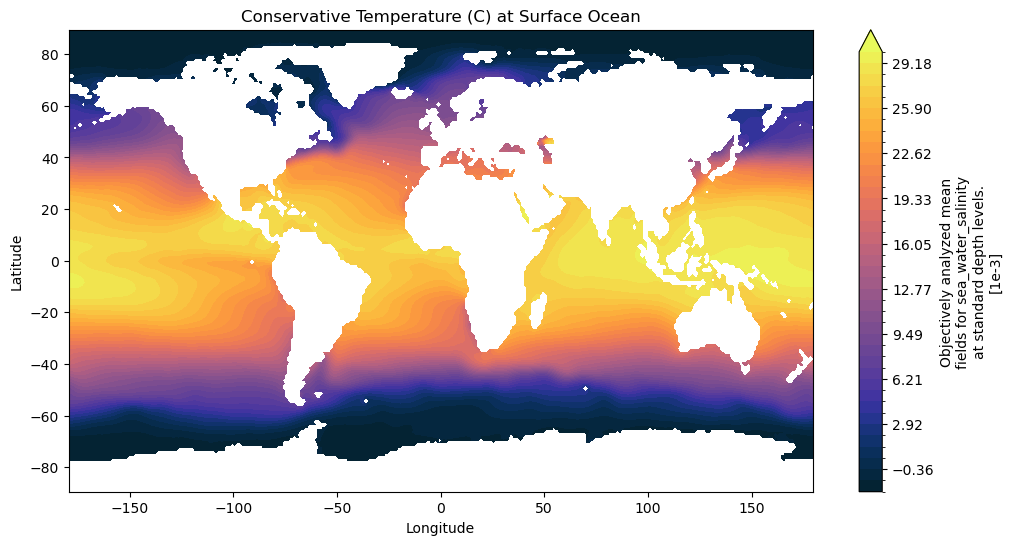

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

conservative_temp.sel(depth='0.00e+00').plot.contourf(vmin=-2, vmax=30, cmap=cmocean.cm.thermal, levels=40)

ax.set_title('Conservative Temperature (C) at Surface Ocean')

ax.set_ylabel('Latitude')

ax.set_xlabel('Longitude')

Text(0.5, 0, 'Longitude')

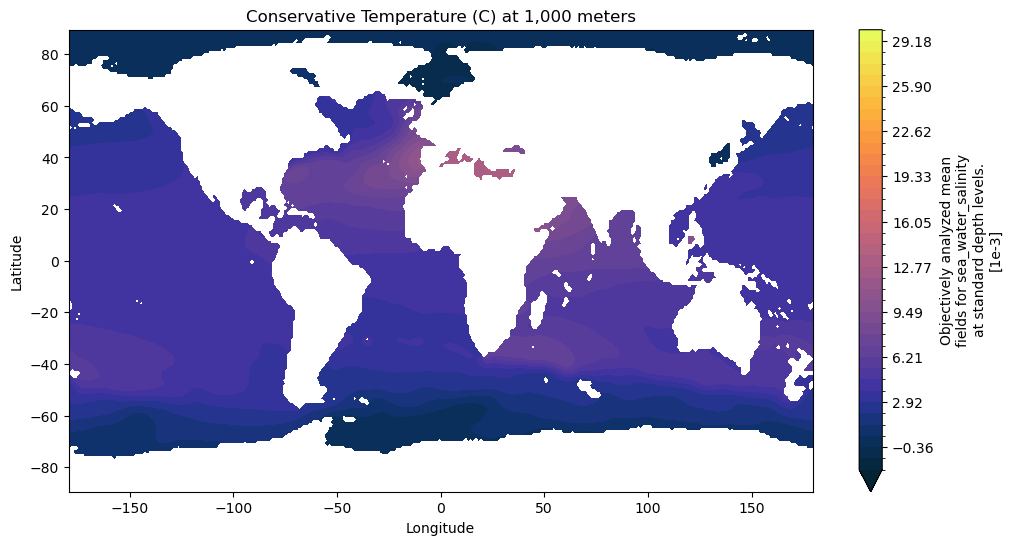

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

conservative_temp.sel(depth='1.00e+03').plot.contourf(vmin=-2, vmax=30, cmap=cmocean.cm.thermal, levels=40)

ax.set_title('Conservative Temperature (C) at 1,000 meters')

ax.set_ylabel('Latitude')

ax.set_xlabel('Longitude')

Text(0.5, 0, 'Longitude')

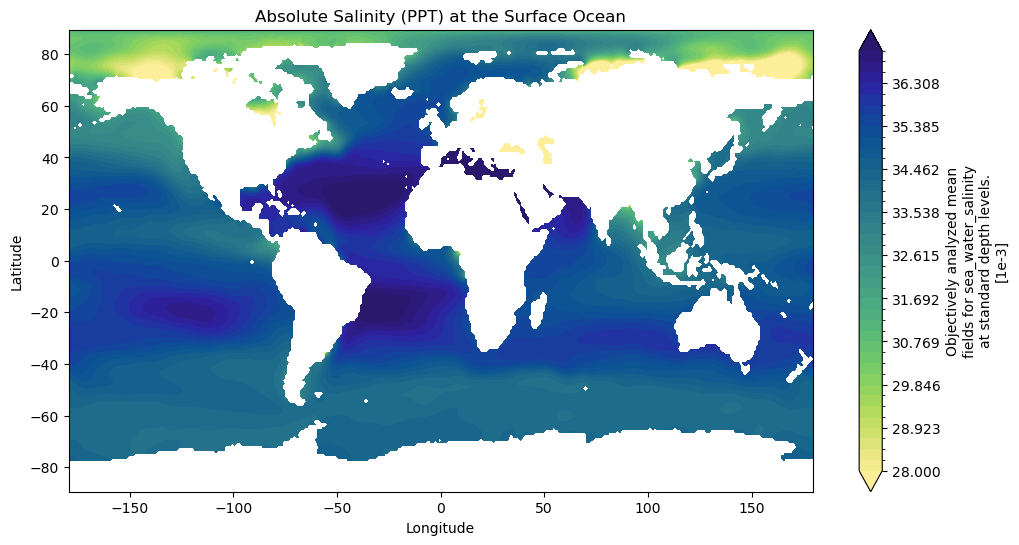

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))

absolute_salt.sel(depth='0.00e+00').plot.contourf(vmin=28, vmax=37, cmap=cmocean.cm.haline_r, levels=40)

ax.set_title('Absolute Salinity (PPT) at the Surface Ocean')

ax.set_ylabel('Latitude')

ax.set_xlabel('Longitude')

Text(0.5, 0, 'Longitude')

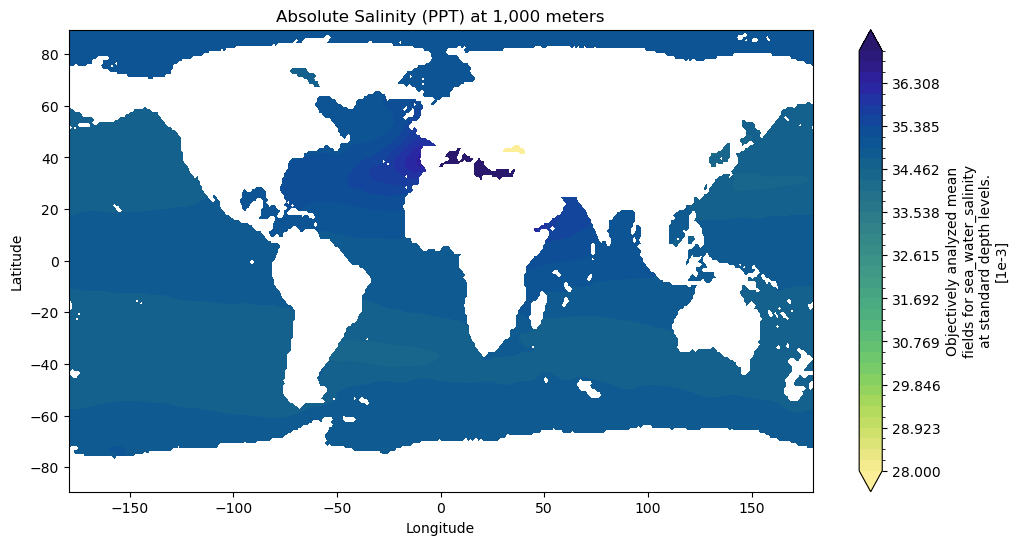

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))

absolute_salt.sel(depth='1.00e+03').plot.contourf(vmin=28, vmax=37, cmap=cmocean.cm.haline_r, levels=40)

ax.set_title('Absolute Salinity (PPT) at 1,000 meters')

ax.set_ylabel('Latitude')

ax.set_xlabel('Longitude')

Text(0.5, 0, 'Longitude')

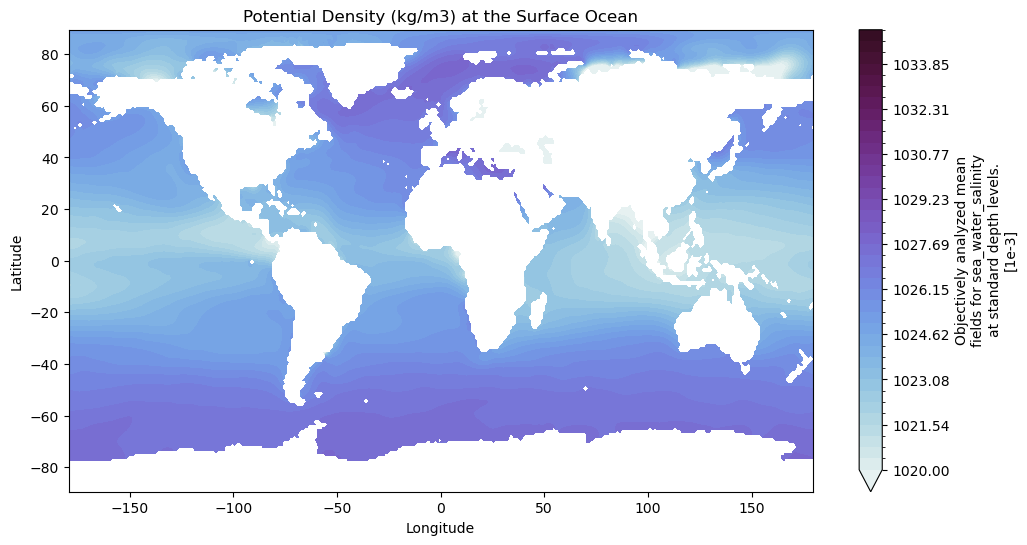

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

potential_density.sel(depth='0.00e+00').plot.contourf(vmin=1020, vmax=1035, cmap=cmocean.cm.dense, levels=40)

ax.set_title('Potential Density (kg/m3) at the Surface Ocean')

ax.set_ylabel('Latitude')

ax.set_xlabel('Longitude')

Text(0.5, 0, 'Longitude')

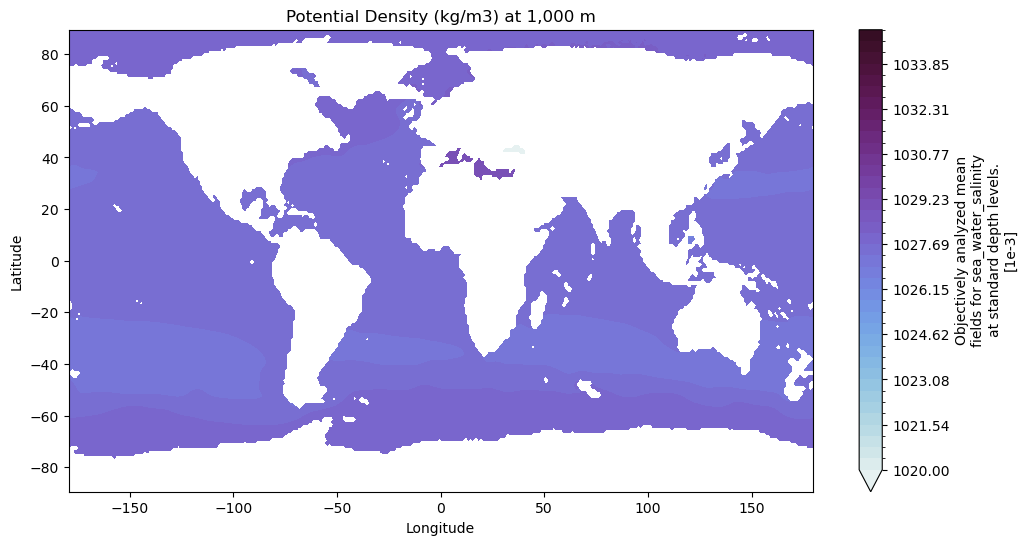

In [27]:
fig, ax = plt.subplots(figsize=(12, 6))

potential_density.sel(depth='1.00e+03').plot.contourf(vmin=1020, vmax=1035, cmap=cmocean.cm.dense, levels=40)

ax.set_title('Potential Density (kg/m3) at 1,000 m')

ax.set_ylabel('Latitude')

ax.set_xlabel('Longitude')

### todo: Write a few sentences about the patterns you observe (i.e. why is it warmer or saltier in certain regions?)

The temperature is the highest at the equator. The Earth is a sphere, so the Sun’s light/heat is concentrated towards the center of the sphere. At 1,000m the temperature has decreased dramatically from the surface values. The Sun’s warmth is highest at the surface ocean because it is in direct contact. Light only penetrates to ~200 meters at the max, so the amount of heat will decrease the deeper you go. The salinity is the highest in the sub-tropical region due to low precipitation and high evaporation. The lowest salinity is near the poles where there is more precipitation and less evaporation. Another factor is the melting of ice sheets and glaciers in the polar regions. At 1,000m depth the salinity is overall higher than the surface values. The Dead Sea still has very high salinity, as it is the saltiest sea on Earth. Temperature and salinity both impact the density of seawater. At the surface the density of seawater is higher in the polar regions due to cold water being denser, this lines up with the cold regions shown on the surface temperature map. The less dense water at the surface is near the equator because of the concentrated sunlight in that area, and warm water is less dense. The deeper into the water column for each parameter, the more consistent they become. This is because there is less of an influence of the sun and precipitation on these parameters.

### todo: Plot a cross section of potential density at 30W longitude (across all latitudes)

Text(0.5, 0, 'Latitude')

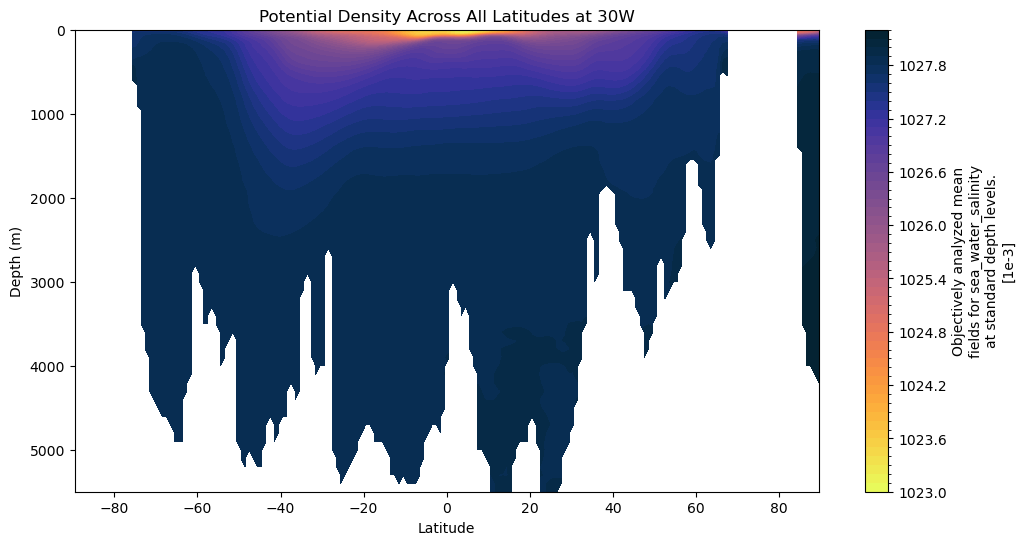

In [28]:
fig, ax = plt.subplots(figsize=(12, 6))

potential_density.sel(lon=-30.5).plot.contourf(yincrease=False, levels=60, cmap=cmocean.cm.thermal_r)

ax.set_title('Potential Density Across All Latitudes at 30W')

ax.set_ylabel('Depth (m)')

ax.set_xlabel('Latitude')

### todo: Along this cross-section, estimate and plot horizontal gradients of potential density ($\frac{\partial \sigma_0}{\partial y}$) 

(consider using the centered difference method and ignoring the latitudes for which a centered difference would be incomplete)

In [29]:
full_depth = potential_density.depth.values

In [30]:
dy = np.diff(potential_density.lat).mean() * 111e3  #Converts latitude degrees to meters, there are approximately 111km in a degree of latitude

In [31]:
dy

111000.0

In [32]:
rho_section = potential_density.sel(lon=-30.5)

In [33]:
rho = rho_section.transpose('lat', 'depth').values

In [34]:
d_rho_dy = np.zeros_like(rho)

In [35]:
d_rho_dy[1:-1, :] = (rho[2:, :] - rho[:-2, :]) / (2 * dy)

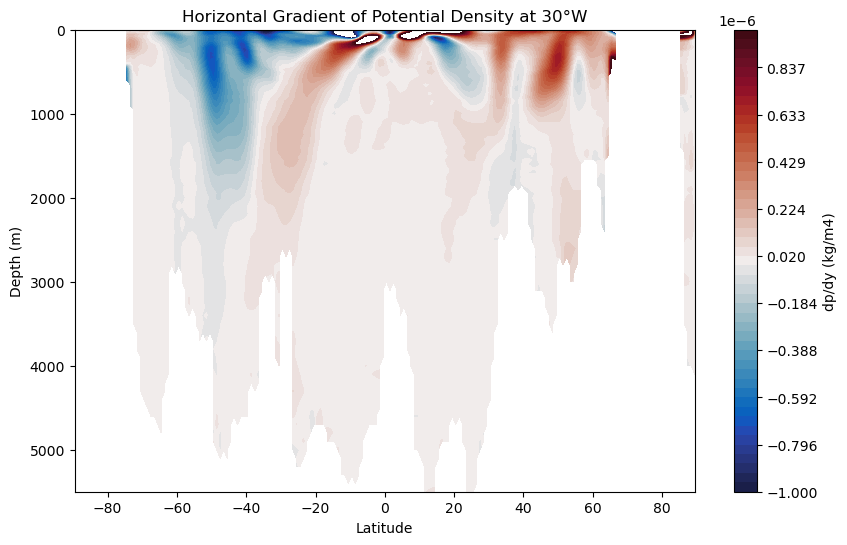

In [36]:
plt.figure(figsize=(10,6))

cf = plt.contourf(potential_density.lat, full_depth, d_rho_dy.T, levels=np.linspace(-1e-6, 1e-6, 50), cmap=cmocean.cm.balance)

plt.gca().invert_yaxis()

cbar = plt.colorbar(cf)
cbar.set_label('dp/dy (kg/m4)')

plt.xlabel('Latitude')
plt.ylabel('Depth (m)')
plt.title('Horizontal Gradient of Potential Density at 30°W')
plt.show()

### with horizontal gradients of potential density, we can estimate the vertical shear of zonal velocities as

$\Large\frac{\partial u}{\partial z} = \frac{g}{\rho_0 f} \frac{\partial \sigma_0}{\partial y}$

todo: evaluate the right hand side (compute and plot $\frac{\partial u}{\partial z}$)

In [37]:
g = 9.81
rho0 = 1025
Omega = 7.2921e-5

lat = potential_density.lat.values      
phi = np.deg2rad(lat)
f = 2 * Omega * np.sin(phi)

In [38]:
du_dz_calc = (g / (rho0 * f)) * d_rho_dy.T

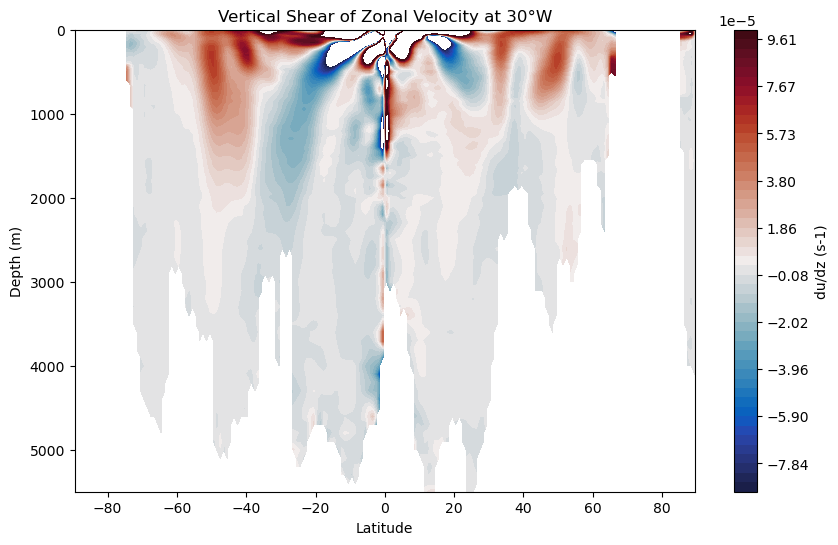

In [39]:
plt.figure(figsize=(10,6))

cf = plt.contourf(lat, full_depth, du_dz_calc, levels=np.linspace(-0.9e-4, 1e-4, 50), cmap=cmocean.cm.balance)

plt.gca().invert_yaxis()

cbar = plt.colorbar(cf)
cbar.set_label('du/dz (s-1)')

plt.xlabel('Latitude')
plt.ylabel('Depth (m)')
plt.title('Vertical Shear of Zonal Velocity at 30°W')
plt.show()

### todo: select 1000 m as your reference level (or level of no motion) and cumulatively integrate from z = -1000 m to the surface to obtain a profile of zonal velocity $u$

We'll first ignore everything below z = -1000 m and assume $u$ is zero at z = -1000 m. At each latitude, calculate a cumulative vertical  sum of the right hand side, at each level multiplied by $dz$ (the vertical distance separating values), upwards from z = -1000 m ... this approximates a $du$ that when cumulatively summed approximated the total vertical integral.

todo: plot $u$ over this cross-section and across this depth range (spanning all latitudes between z = 0 m and z = -1000 m)

In [40]:
depth_slice = potential_density.sel(lon=-30.5)

In [41]:
depth_1000 = depth_slice.sel(depth=slice(0,1000))

In [42]:
du_dz_da = xr.DataArray(du_dz_calc, coords=[full_depth, lat], dims=['depth','lat'])

In [43]:
shear_1000 = du_dz_da.sel(depth=slice(0,1000))

In [44]:
dz_1000 = depth_1000.diff("depth")

In [57]:
dz_da_1000 = xr.DataArray(dz_1000, coords=[shear_1000.depth.isel(depth=slice(1,None)), lat],
                     dims=['depth', 'lat'])

In [46]:
shear_mid_1000 = shear_1000.isel(depth=slice(1,None))

In [53]:
cs_shear_1000 = np.cumsum(shear_mid_1000)

In [54]:
u_profile_1000 = cs_shear_1000 * dz_da_1000

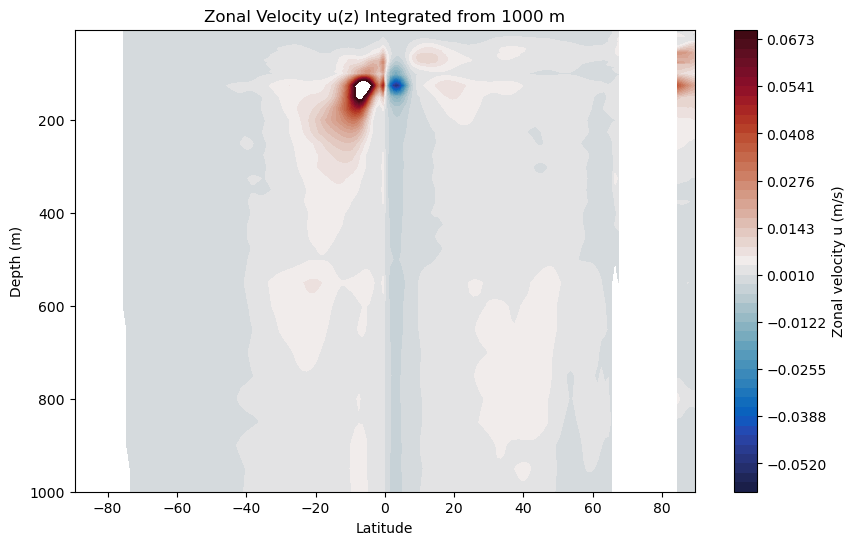

In [55]:
plt.figure(figsize=(10,6))
cf = plt.contourf(lat, u_profile_1000.depth, u_profile_1000, levels=np.linspace(-0.06, 0.07, 50), cmap=cmocean.cm.balance)
plt.gca().invert_yaxis()
cbar = plt.colorbar(cf)
cbar.set_label('Zonal velocity u (m/s)')
plt.xlabel('Latitude')
plt.ylabel('Depth (m)')
plt.title('Zonal Velocity u(z) Integrated from 1000 m')
plt.show()

### todo: redo the above calculation starting at z = -3000 m and then again at the seafloor

In [384]:
depth_3000 = depth_slice.sel(depth=slice(0,3000))

In [385]:
shear_3000 = du_dz_da.sel(depth=slice(0,3000))

In [386]:
dz_3000 = depth_3000.diff("depth")

In [387]:
dz_da_3000 = xr.DataArray(dz_3000, coords=[shear_3000.depth.isel(depth=slice(1,None)), lat],
                     dims=['depth', 'lat'])

In [388]:
shear_mid_3000 = shear_3000.isel(depth=slice(1,None))

In [389]:
cs_shear_3000 = np.cumsum(shear_mid_3000)

In [390]:
u_profile_3000 = cs_shear_3000 * dz_da_3000

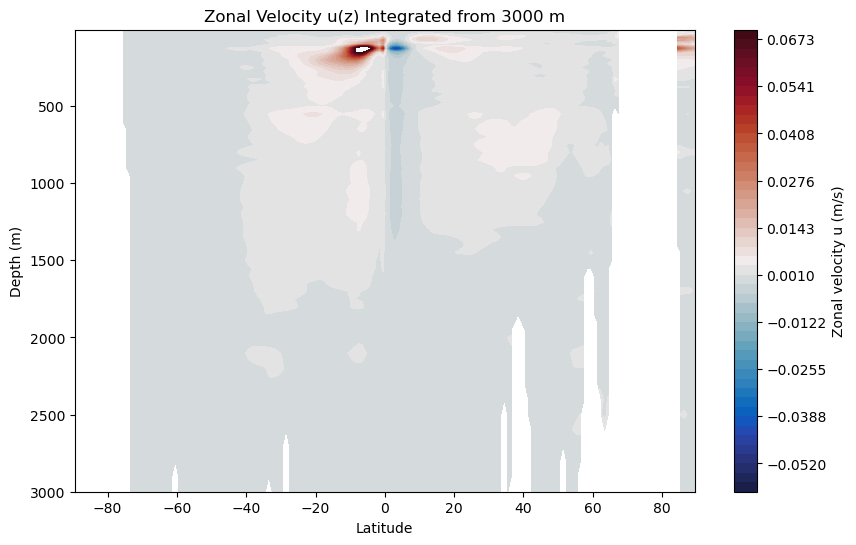

In [407]:
plt.figure(figsize=(10,6))
cf = plt.contourf(lat, u_profile_3000.depth, u_profile_3000, levels=np.linspace(-0.06, 0.07, 50), cmap=cmocean.cm.balance)
plt.gca().invert_yaxis()
cbar = plt.colorbar(cf)
cbar.set_label('Zonal velocity u (m/s)')
plt.xlabel('Latitude')
plt.ylabel('Depth (m)')
plt.title('Zonal Velocity u(z) Integrated from 3000 m')
plt.show()

In [399]:
depth_sf = depth_slice.sel(depth=slice(0,5500))

In [400]:
shear_sf = du_dz_da.sel(depth=slice(0,5500))

In [401]:
dz_sf = depth_sf.diff("depth")

In [402]:
dz_da_sf = xr.DataArray(dz_sf, coords=[shear_sf.depth.isel(depth=slice(1,None)), lat],
                     dims=['depth', 'lat'])

In [403]:
shear_mid_sf = shear_sf.isel(depth=slice(1,None))

In [404]:
cs_shear_sf = np.cumsum(shear_mid_sf)

In [405]:
u_profile_sf = cs_shear_sf * dz_da_sf

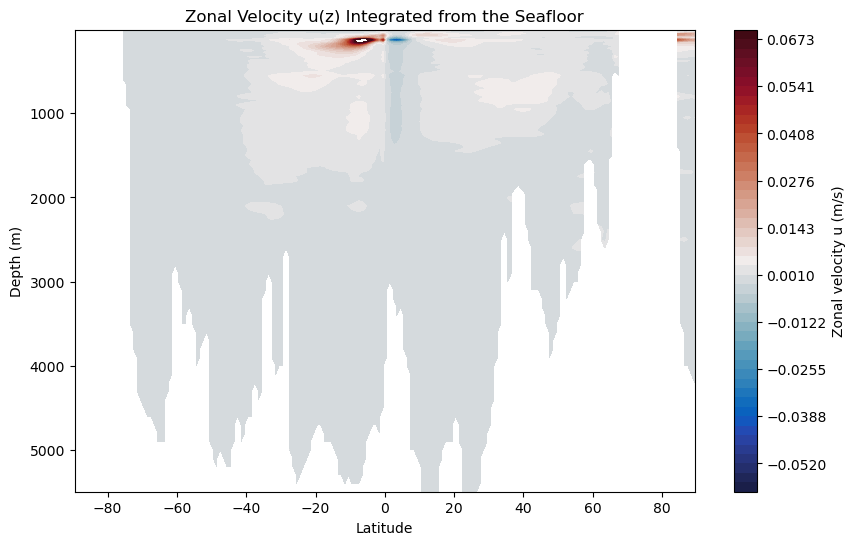

In [408]:
plt.figure(figsize=(10,6))
cf = plt.contourf(lat, u_profile_sf.depth, u_profile_sf, levels=np.linspace(-0.06, 0.07, 50), cmap=cmocean.cm.balance)
plt.gca().invert_yaxis()
cbar = plt.colorbar(cf)
cbar.set_label('Zonal velocity u (m/s)')
plt.xlabel('Latitude')
plt.ylabel('Depth (m)')
plt.title('Zonal Velocity u(z) Integrated from the Seafloor')
plt.show()

### todo: consider how estimates of $u$ over the upper 1000 m change as the refence level deepends. Write a few sentences about these differences, describe the features of $u$ that you observe, and connect them to know currents. 

u is the zonal velocity which is the velocity of flow in the East and West direction. A positive u is a flow in the East and a negative u is a flow in the West. du is how the East and West velocity changes with depth. There is a positive u around 100-300 meters, this is showing the Equatorial Undercurrent that is flowing East. The negative u flowing West in the is from the trade winds that come from the East and flow West. u becomes smaller with deeper integration into the water column. There is very low u in the deeper ocean. My thought is that since currents rely heavily on wind stress and stratification, those are very low the deeper into the water column so u would be smaller.